# Gene Expression Analysis under Oxidative Stress

## Section 3: Differential Expression & Biological Insights

In this notebook, we analyze gene expression differences between conditions and identify biologically relevant patterns.

This includes:
- Differential expression analysis
- Volcano plot visualization
- Heatmap of top genes
- Identification of key upregulated and downregulated genes
- Analysis of oxidative stress effects (H2O2)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [102]:
df_counts_filtered = pd.read_csv('../data/counts_filtered.csv', index_col=0)

In [103]:
# CPM normalization
df_cpm = df_counts_filtered.div(df_counts_filtered.sum(axis=0), axis=1) * 1_000_000

# Log transform
df_log_cpm = np.log2(df_cpm + 1)

print("Data loaded and preprocessed ✓")

Data loaded and preprocessed ✓


### 1. Differential Expression Analysis

We identify genes that are differentially expressed between normal (HPNE) and tumor (PANC1) samples.

This analysis includes:
- Calculation of log2 fold change
- Statistical testing (t-test)
- Identification of significant genes

#### Group Definition

To compare gene expression between conditions, we first separate the samples into two biological groups:

- HPNE: normal pancreatic cells  
- PANC1: tumor pancreatic cells  

This allows us to compute statistics independently for each condition.

In [104]:
# Separate groups
hpne_cols = ["HPNE_Control", "HPNE_H2O2"]
panc1_cols = ["PANC1_Control", "PANC1_H2O2"]

df_hpne = df_log_cpm[hpne_cols]
df_panc1 = df_log_cpm[panc1_cols]

print("Groups separated ✓")
print("HPNE shape:", df_hpne.shape)
print("PANC1 shape:", df_panc1.shape)

Groups separated ✓
HPNE shape: (30936, 2)
PANC1 shape: (30936, 2)


#### Fold Change Calculation

We compute the average expression of each gene within each group and calculate the log2 fold change.

This metric represents the magnitude of change between tumor and normal samples.

In [105]:
# Compute mean expression per group
mean_hpne = df_hpne.mean(axis=1)
mean_panc1 = df_panc1.mean(axis=1)

# Log2 Fold Change
log2_fc = mean_panc1 - mean_hpne

print("Fold change calculated ✓")

Fold change calculated ✓


#### Statistical Testing

To assess whether the observed differences in gene expression are statistically significant, we perform a t-test for each gene.

This helps distinguish true biological differences from random variation.

In [106]:
# Compute p-values using t-test
p_values = []

for gene in df_log_cpm.index:
    stat, p = stats.ttest_ind(
        df_panc1.loc[gene],
        df_hpne.loc[gene],
        equal_var=False
    )
    p_values.append(p)

p_values = pd.Series(p_values, index=df_log_cpm.index)

print("Statistical testing complete ✓")

Statistical testing complete ✓


#### Results Table

We combine the fold change and p-values into a single dataframe for downstream analysis and visualization.

Additionally, we compute the -log10(p-value) for better interpretability in plots.

In [107]:
# Create results dataframe
df_de = pd.DataFrame({
    "log2FC": log2_fc,
    "p_value": p_values
})

# Add -log10(p-value)
df_de["-log10_p"] = -np.log10(df_de["p_value"])

df_de.head()

,log2FC,p_value,-log10_p
Symbol,,,
DDX11L1,0.215579,0.112175,0.950102
WASH7P,0.600971,0.122200,0.912929
MIR6859-1,0.317135,0.326383,0.486272
FAM138A,-0.029385,0.275029,0.560621
LOC100996442,-0.289188,0.460066,0.337180


#### Significant Genes Selection

We define thresholds for fold change and p-value to identify significantly differentially expressed genes.

These genes are likely to be biologically relevant.

In [108]:
# Define thresholds
log2fc_threshold = 1
pval_threshold = 0.05

df_de["significant"] = (
    (abs(df_de["log2FC"]) > log2fc_threshold) &
    (df_de["p_value"] < pval_threshold)
)

print("Significant genes:", df_de["significant"].sum())

Significant genes: 4021


#### Interpretation of Results

A large number of genes were identified as significantly differentially expressed between normal and tumor samples.

This may be influenced by the small sample size, which can increase variability and affect statistical significance.

Nevertheless, the results provide an initial overview of potential biological differences between conditions.

### 2. Volcano Plot

We visualize differential expression results using a volcano plot.

This plot shows:
- Log2 fold change (magnitude of change)
- -log10(p-value) (statistical significance)

Significant genes are highlighted to identify key biological differences.

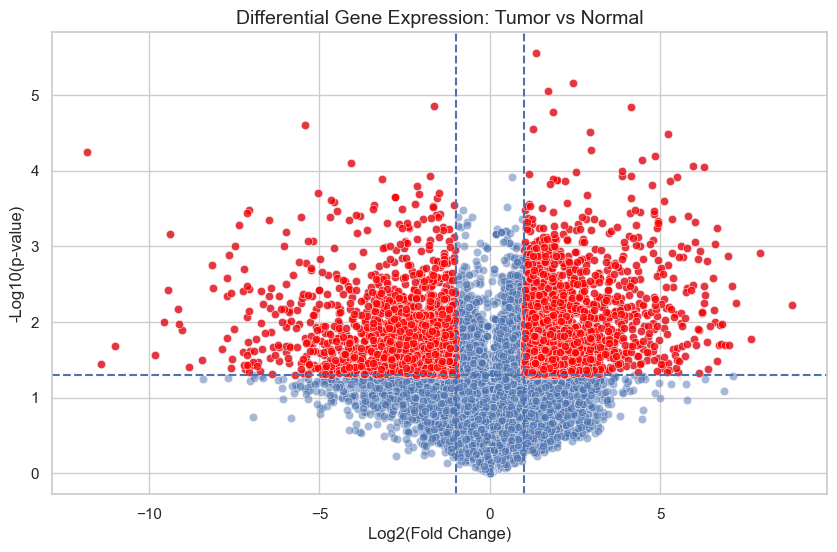

In [109]:
# Volcano plot

plt.figure(figsize=(10,6))

# Plot all genes
sns.scatterplot(
    x=df_de["log2FC"],
    y=df_de["-log10_p"],
    alpha=0.5
)

# Highlight significant genes
sns.scatterplot(
    x=df_de[df_de["significant"]]["log2FC"],
    y=df_de[df_de["significant"]]["-log10_p"],
    color="red",
    alpha=0.7
)

plt.title("Differential Gene Expression: Tumor vs Normal", fontsize=14)
plt.xlabel("Log2(Fold Change)")
plt.ylabel("-Log10(p-value)")

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.show()

#### Volcano Plot Interpretation

The volcano plot highlights genes with both strong changes in expression and high statistical significance.

Genes located in the upper left and right regions represent the most relevant candidates, showing significant differential expression between normal and tumor samples.

The high number of significant genes suggests substantial variation between conditions, although results should be interpreted cautiously due to the limited sample size.

### 3. Heatmap of Top Differentially Expressed Genes

To further explore expression patterns across samples, we visualize the top differentially expressed genes using a heatmap.

This allows us to observe clustering patterns and assess whether samples group according to biological conditions.

In [110]:
# Create dataframe with only significant genes
df_significant = df_de[df_de["significant"]]

In [111]:
# Select top significant genes
top_genes = df_significant.sort_values(by="p_value").head(50).index

df_heatmap = df_log_cpm.loc[top_genes]

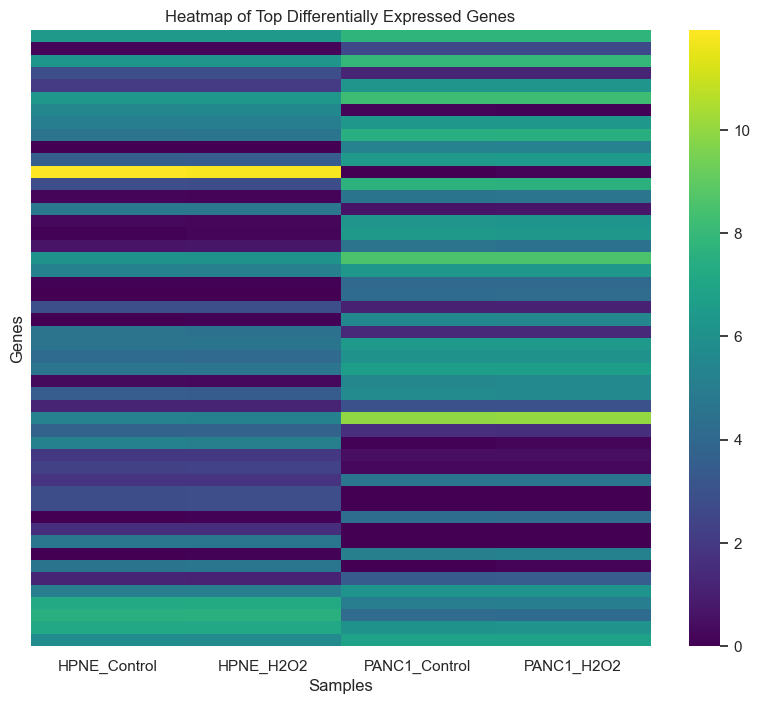

In [112]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_heatmap,
    cmap="viridis",
    yticklabels=False
)

plt.title("Heatmap of Top Differentially Expressed Genes")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.show()

#### Heatmap Interpretation

The heatmap shows clear differences in gene expression patterns between normal (HPNE) and tumor (PANC1) samples.

Genes exhibit consistent expression profiles within each cell type, with noticeable differences between HPNE and PANC1 groups, supporting the results of the differential expression analysis.

Within each cell type, control and H2O2-treated samples appear relatively similar, suggesting that the primary source of variation in this dataset is the difference between normal and tumor cells rather than the oxidative stress condition.

Overall, these patterns reinforce the presence of distinct biological signatures associated with each cell type.

### 4. Top Differentially Expressed Genes

To better understand the biological differences between conditions, we identify the most upregulated and downregulated genes based on log2 fold change and statistical significance.

These genes represent the strongest candidates for differential expression between normal and tumor samples.

#### Top Upregulated Genes

We identify the genes with the highest log2 fold change, representing those most overexpressed in tumor (PANC1) samples compared to normal (HPNE).

In [113]:
# Top upregulated genes (highest log2FC)
top_up = df_de.sort_values(by="log2FC", ascending=False).head(10)

top_up

,log2FC,p_value,-log10_p,significant
Symbol,,,,
RPS16,8.869313,0.005863,2.231915,True
KRT19,7.938058,0.001231,2.909747,True
BIRC3,7.671133,0.016513,1.782179,True
KIF1A,7.224376,0.005541,2.256382,True
H2BC13,7.151412,0.051474,1.288411,False
FBXO27,7.118104,0.003338,2.476484,True
SPINT2,7.019609,0.020378,1.690837,True
TPD52,6.978577,0.001320,2.879555,True
RHPN2,6.904824,0.020281,1.692906,True


#### Top Downregulated Genes

We identify the genes with the lowest log2 fold change, representing those more highly expressed in normal (HPNE) samples compared to tumor (PANC1).

In [114]:
# Top downregulated genes (lowest log2FC)
top_down = df_de.sort_values(by="log2FC", ascending=True).head(10)

top_down

,log2FC,p_value,-log10_p,significant
Symbol,,,,
GREM1,-11.805089,0.000056,4.255250,True
FN1,-11.398700,0.036196,1.441340,True
COL1A2,-10.991303,0.020779,1.682377,True
COL1A1,-9.815470,0.027286,1.564067,True
MIR3648-2,-9.571073,0.010021,1.999107,True
MIR3648-1,-9.452308,0.003774,2.423193,True
SPARC,-9.379346,0.000689,3.161717,True
DCN,-9.142859,0.006741,2.171256,True
COL6A3,-9.122154,0.010471,1.980024,True


#### Filtering Significant Genes

To focus on the most reliable results, we filter genes based on statistical significance and fold change thresholds.

This ensures that selected genes show both strong expression changes and statistical support.

In [115]:
# Only significant genes
df_significant = df_de[df_de["significant"]]

top_up_sig = df_significant.sort_values(by="log2FC", ascending=False).head(10)
top_down_sig = df_significant.sort_values(by="log2FC", ascending=True).head(10)

top_up_sig, top_down_sig

(           log2FC   p_value  -log10_p  significant
 Symbol                                            
 RPS16    8.869313  0.005863  2.231915         True
 KRT19    7.938058  0.001231  2.909747         True
 BIRC3    7.671133  0.016513  1.782179         True
 KIF1A    7.224376  0.005541  2.256382         True
 FBXO27   7.118104  0.003338  2.476484         True
 SPINT2   7.019609  0.020378  1.690837         True
 TPD52    6.978577  0.001320  2.879555         True
 RHPN2    6.904824  0.020281  1.692906         True
 H2BC14   6.825705  0.010701  1.970578         True
 ALDH1A3  6.779378  0.019485  1.710294         True,
               log2FC   p_value  -log10_p  significant
 Symbol                                               
 GREM1     -11.805089  0.000056  4.255250         True
 FN1       -11.398700  0.036196  1.441340         True
 COL1A2    -10.991303  0.020779  1.682377         True
 COL1A1     -9.815470  0.027286  1.564067         True
 MIR3648-2  -9.571073  0.010021  1.999107    

#### Interpretation of Top Genes

The top upregulated genes show higher expression in tumor samples, suggesting potential involvement in cancer-related processes.

Notably, several genes identified in this group are associated with cellular proliferation and survival, which are commonly altered in tumor conditions.

Conversely, many of the top downregulated genes (e.g., COL1A1, COL1A2, SPARC) are related to extracellular matrix organization and structural functions. This suggests a potential disruption of normal tissue architecture in tumor cells.

These findings highlight biologically relevant differences between normal and tumor samples, and identify strong candidates for further investigation.

### 5. Effect of Oxidative Stress (H2O2)

To investigate the impact of oxidative stress, we analyze gene expression changes between control and H2O2-treated samples within each cell type.

This allows us to evaluate how normal (HPNE) and tumor (PANC1) cells respond to oxidative stress conditions.

In [116]:
# HPNE: Control vs H2O2
hpne_control = df_log_cpm["HPNE_Control"]
hpne_h2o2 = df_log_cpm["HPNE_H2O2"]

# PANC1: Control vs H2O2
panc1_control = df_log_cpm["PANC1_Control"]
panc1_h2o2 = df_log_cpm["PANC1_H2O2"]

print("Groups for oxidative stress analysis ready ✓")

Groups for oxidative stress analysis ready ✓


In [117]:
# Compute log2 fold change for H2O2 effect

log2fc_hpne_stress = hpne_h2o2 - hpne_control
log2fc_panc1_stress = panc1_h2o2 - panc1_control

print("Fold change for oxidative stress calculated ✓")

Fold change for oxidative stress calculated ✓


In [118]:
df_stress = pd.DataFrame({
    "log2FC_HPNE": log2fc_hpne_stress,
    "log2FC_PANC1": log2fc_panc1_stress
})

df_stress.head()

,log2FC_HPNE,log2FC_PANC1
Symbol,,
DDX11L1,0.119686,-0.095347
WASH7P,0.349507,0.290345
MIR6859-1,0.370818,0.318361
FAM138A,0.001540,-0.027194
LOC100996442,0.514278,0.075126


### Identification of Genes Most Affected by Oxidative Stress

To better understand the impact of oxidative stress, we rank genes based on the magnitude of their expression changes.

We compute the absolute log2 fold change to identify genes that are most strongly upregulated or downregulated in response to H2O2 treatment.

This analysis is performed separately for normal (HPNE) and tumor (PANC1) cells.

In [119]:
df_stress["abs_HPNE"] = df_stress["log2FC_HPNE"].abs()
df_stress["abs_PANC1"] = df_stress["log2FC_PANC1"].abs()

df_stress.sort_values("abs_HPNE", ascending=False).head(10)

,log2FC_HPNE,log2FC_PANC1,abs_HPNE,abs_PANC1
Symbol,,,,
HSPA6,7.321269,1.301396,7.321269,1.301396
GDF15,5.711563,1.461792,5.711563,1.461792
RRAD,5.027298,0.461866,5.027298,0.461866
HSPA7,4.670300,0.329917,4.670300,0.329917
H3C12,-4.342545,-1.224015,4.342545,1.224015
H3C8,-4.080518,0.074182,4.080518,0.074182
ARC,3.982336,0.407671,3.982336,0.407671
CDKN1A,3.924122,1.001833,3.924122,1.001833
BTG2,3.852363,0.331709,3.852363,0.331709


### Differential Response Between Normal and Tumor Cells

To identify genes that respond differently to oxidative stress between cell types, we compute the difference in log2 fold change between PANC1 and HPNE cells.

This allows us to highlight genes with contrasting responses, which may indicate altered stress response mechanisms in tumor cells.

In [120]:
df_stress["difference"] = df_stress["log2FC_PANC1"] - df_stress["log2FC_HPNE"]

df_stress.sort_values("difference", ascending=False).head(10)

,log2FC_HPNE,log2FC_PANC1,abs_HPNE,abs_PANC1,difference
Symbol,,,,,
H3C8,-4.080518,0.074182,4.080518,0.074182,4.154699
LOC105379549,-3.815671,-0.149255,3.815671,0.149255,3.666416
H3C7,-3.475671,0.000000,3.475671,0.000000,3.475671
H4C9,-3.492671,-0.307331,3.492671,0.307331,3.185340
H3C12,-4.342545,-1.224015,4.342545,1.224015,3.118530
HJURP,-3.045661,-0.129867,3.045661,0.129867,2.915794
H2BC9,-2.971289,-0.055542,2.971289,0.055542,2.915747
H3C13,-3.342185,-0.492201,3.342185,0.492201,2.849984
CCNA2,-3.135935,-0.347967,3.135935,0.347967,2.787968


### Interpretation of Oxidative Stress Response

The analysis of gene expression changes under oxidative stress (H2O2 treatment) reveals notable differences between normal (HPNE) and tumor (PANC1) cells.

In normal cells, several genes exhibit strong expression changes, indicating an active response to oxidative stress. These include genes involved in stress response pathways, such as heat shock proteins and regulatory genes.

In contrast, tumor cells show a more attenuated response, with smaller changes in gene expression across the same genes. This suggests that tumor cells may be less sensitive to oxidative stress or have developed mechanisms to cope with it.

Additionally, some genes display contrasting behavior between cell types, being strongly regulated in normal cells but showing minimal or no change in tumor cells. This differential response highlights potential alterations in stress-response pathways in cancer cells.

Overall, these results suggest that tumor cells exhibit a reduced or altered response to oxidative stress, which may contribute to their survival and adaptability under adverse conditions.